# Machine Learning HW 3: Boosting Decision Trees & Random Forest

## Part1: Determining Splits

In [3]:
from IPython.display import Markdown, display
with open("Homework_3_Part1.txt", "r", encoding="utf-8") as f:
    display(Markdown(f.read()))

**[Homework3-Part1: Mushroom Decision Tree (Manual Calculation)]**

### Dataset summary:
- Total samples |S| = 12
- Target y = Poisonous?: Y = 5, N = 7

### Formulas
$H(Y) = - Σ p(y) * log2 p(y)$

$H(Y|A) = Σ_v (|S_v| / |S|) * H(Y in S_v)$

$IG(Y, A) = H(Y) - H(Y|A)$

-------------------------------------------------
### Step 1. Target entropy H(Y)

$p(Y) = 5/12, p(N) = 7/12$

$H(Y) = - (5/12)*log2(5/12) - (7/12)*log2(7/12) = 0.979869$

-------------------------------------------------

### Step 2. Evaluate information gain for each attribute

#### (1) A = x1 (size, continuous)

  - Unique values: {1, 2, 3, 4, 5}
  - Possible split points: t ∈ {1.5, 2.5, 3.5, 4.5}
  - The best split is at t = 3.5

  Left side (≤ 3.5): $|S_L| = 7 → Y = 2, N = 5 → H_L = - (2/7)*log2(2/7) - (5/7)*log2(5/7) = 0.863121$

  Right side (> 3.5): $|S_R| = 5 → Y = 3, N = 2 → H_R = - (3/5)*log2(3/5) - (2/5)*log2(2/5) = 0.9709501$
  
  $H(Y|x1 @ 3.5) = (7/12)*0.863121 + (5/12)*0.9709501 = 0.908050$
  $IG(Y, x1 @ 3.5) = 0.979869 - 0.908050 = 0.071819$


#### (2) A = x2 (spots: Y/N)

  $spots = N: |S_N| = 5 → Y = 0, N = 5 → H_N = 0$

  $spots = Y: |S_Y| = 7 → Y = 5, N = 2 → H_Y = - (5/7)*log2(5/7) - (2/7)*log2(2/7) = 0.863121$

  $H(Y|x2) = (5/12)*0 + (7/12)*0.863121 = 0.503487$
  $IG(Y, x2) = 0.979869 - 0.503487 = 0.476382$ ← largest

#### (3) A = x3 (color: White/Brown)
  
  $color = White: |S_W| = 6 → Y = 2, N = 4 → H_W = - (2/6)*log2(2/6) - (4/6)*log2(4/6) = 0.918296$

  $color = Brown: |S_B| = 6 → Y = 3, N = 3 → H_B = - (3/6)*log2(3/6) - (3/6)*log2(3/6) = 1$
  $H(Y|x3) = (6/12)*0.918296 + (6/12)*1 = 0.959148$
  $IG(Y, x3) = 0.979869 - 0.959148 = 0.020721$

Conclusion: Root node splits on x2 (spots: Y/N).

-------------------------------------------------
### Step 3. Continue splitting the right branch (spots: Y)

$spotsY subset S_Y: |S_Y| = 7, Y = 5, N = 2, H(S_Y) = 0.863121$

#### Candidate A = x1 (size 3.5)
  In S_Y:
  $Left side (≤ 3.5): |S_YL| = 4 → Y = 2, N = 2 → H_YL = - (2/4)*log2(2/4) - (2/4)*log2(2/4) = 1$
  $Right side (> 3.5): |S_YR| = 3 → Y = 3, N = 0 → H_YR = 0$
  $H(Y|x1@ 3.5, S_Y) = (4/7)*1 + (3/7)*0 = 0.571429$
  $IG(S_Y, x1@ 3.5) = 0.863121 - 0.571429 = 0.291692$ ← largest

#### Candidate B = x3 (color)
  In S_Y:
  $color = White: |S_YW| = 3 → Y = 2, N = 1 → H_YY = - (2/3)*log2(2/3) - (1/3)*log2(1/3) = 0.918296$
  $color = Brown: |S_YB| = 4 → Y = 3, N = 1 → H_YN = - (3/4)*log2(3/4) - (1/4)*log2(1/4) = 0.811278$
  $H(Y|x3, S_Y) = (3/7)*0.918296 + (4/7)*0.811278 = 0.857143$
  $IG(S_Y, x3) = 0.863121 - 0.857143 = 0.005978$

Conclusion: First node of spots: Y branch splits on x1 (size 3.5).

-------------------------------------------------
### Step 4. continue splitting the size ≤ 3.5 branch (the spots=Y side)

* At this point, information gain is small, and it is reasonable to stop.
Still, for clarity, we make one more split.

$spotsY-sizeL subset S_YL: |S_Y| = 4, Y = 2, N = 2, H(S_Y) = 1$

#### Candidate A = x1 (size 1.5)
  In S_YL:
  $Left side (≤ 1.5): |S_YLL| = 2 → Y = 2, N = 0 → H_YLL = 0$
  $Right side (> 1.5):|S_YLR| = 2 → Y = 0, N = 2 → H_YLR = 0$
  $H(Y|x1@ 1.5, S_YL) = (2/4)*0 + (2/4)*0 =0$
  $IG(S_YL, x1@ 1.5) = 1 - 0 = 1$ ← largest

#### Candidate B = x3 (color)
  In S_YL:
  $color = White: |S_YLW| = 2 → Y = 1, N = 1 → H_YLW = 1$
  $color = Brown: |S_YLB| = 2 → Y = 1, N = 1 → H_YLB = 1$
  $H(Y|x3, S_YL) = (2/4)*1 + (2/4)*1 =1$
  $IG(S_YL, x3) = 1 -1 = 0$

Conclusion: Second node of spots: Y branch splits on x1 (size 1.5).

-------------------------------------------------
### Step 5. Final Decision Tree (ASCII)

Root: spots = Y?

├── No: Leaf = Non-poisonous (N = 5, Y = 0; H = 0)

└── Yes:

    ├── size(> 3.5) → Leaf = Poisonous (Y = 3, N = 0; H = 0)

    └── size(<= 3.5):

        ├──size(> 1.5) → Leaf = Non-poisonous (Y = 0, N = 2; H = 0)

        └──size(<= 1.5) → Leaf = Poisonous (Y = 2, N = 0;H = 0)


#### 1. What is the entropy of the target variable, “poisonous”?

The entropy (H(Y)) of the target variable measures the impurity or uncertainty of the dataset before any split.

$
H(Y) = - \sum p(y) \log_2 p(y)
$

Given:

* $(p(Y = \text{poisonous}) = 5/12)$
* $(p(Y = \text{non-poisonous}) = 7/12)$

$
H(Y) = -\left(\frac{5}{12}\log_2\frac{5}{12} + \frac{7}{12}\log_2\frac{7}{12}\right)
$
$
H(Y) = -[0.4167 \times (-1.2630) + 0.5833 \times (-0.7859)] = 0.9799
$


#### 2. What is the first attribute a decision tree trained using the entropy and the information gain method

**The first attribute chosen is $x_2 = spots (Yes/No)$**

A decision tree that uses **entropy** and **information gain (IG)** chooses the attribute with the **largest information gain** as the first (root) split.

From the calculations above:

| Attribute     | Information Gain (IG) |
| ------------- | --------------------: |
| (x_1 =) size  |                0.0718 |
| (x_2 =) spots |            **0.4764** |
| (x_3 =) color |                0.0207 |

**Highest IG = 0.4764**, achieved by **x₂ = “spots”**.


#### 3. What is the information gain of this attribute?

**The information gain of this attribute: 0.476382**

The first attribute chosen was
$x_2 = \text{spots (Yes/No)}$
and its Information Gain is computed as:

$IG(Y, x_2) = H(Y) - H(Y|x_2)$

From Step 1 and 2:

* $H(Y) = - (5/12)*log2(5/12) - (7/12)*log2(7/12) = 0.979869$
* $H(Y|x2) = (5/12)*0 + (7/12)*0.863121 = 0.503487$
$IG(Y, x2) = 0.979869 - 0.503487 = 0.476382$

#### 4. Draw the full decision tree learned from this data set.

Root: spots = Y?

├── No: Leaf = Non-poisonous (N = 5, Y = 0; H = 0)

└── Yes:

    ├── size(> 3.5) → Leaf = Poisonous (Y = 3, N = 0; H = 0)

    └── size(<= 3.5):

        ├──size(> 1.5) → Leaf = Non-poisonous (Y = 0, N = 2; H = 0)

        └──size(<= 1.5) → Leaf = Poisonous (Y = 2, N = 0;H = 0)

**Notes:**
- This tree matches my hand calculations:
  - Root split: `spots` (IG ≈ 0.4764)
  - Then on `spots=Y`: split by `size @ 3.5` (IG ≈ 0.2917)
  - Then on `spots=Y & size≤3.5`: split by `size @ 1.5` (IG = 1.0)
- All leaves are pure (H=0), zero training error on the 12 samples.

## Part 2: Decision Tree

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
# File expected in the same folder:
DATA_PATH = "wdbc.data"

# Column names from the UCI description (ID, Diagnosis, 30 numeric features)
column_names = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

# Read the CSV; wdbc.data is comma-separated with no header row
df = pd.read_csv(DATA_PATH, header=None, names=column_names)

# Preview the first few rows
print(df.head())

         ID Diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [21]:
# Diagnosis: 'M' (malignant) or 'B' (benign).
# Map to integers for clarity: M -> 0 (malignant), B -> 1 (benign)
y = df["Diagnosis"].map({"M": 0, "B": 1}).astype(int)

# Use all 30 numeric features; exclude ID and Diagnosis
X = df.drop(columns=["ID", "Diagnosis"])

### 1) Divide the data into train (80%) and test (20%)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42  # fixed seed for reproducibility
)

### 2) Using the approprirate package to train the Decision Tree Classifier using all the features of the data and test your model on the test data

In [27]:
clf = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)
clf.fit(X_train, y_train)
y_pred_test = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)
print("test_accuracy:", test_acc)

test_accuracy: 0.9473684210526315


### 3) Run the model for trees of depth 1, 2, 3, 4, 5, and 6 and for the Gini Impurity and Entropy impurity measures.

In [30]:
results = []   # list of dicts with criterion, depth, test_accuracy
models = {}    # (criterion, depth) -> fitted model

for criterion in ["gini", "entropy"]:
    for depth in range(1, 7):  # depths 1..6
        clf = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=depth,
            random_state=42
        )
        clf.fit(X_train, y_train)
        y_pred_test = clf.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred_test)

        results.append({
            "criterion": criterion,
            "max_depth": depth,
            "test_accuracy": test_acc
        })
        models[(criterion, depth)] = clf

# Collect results in a DataFrame and sort:
# highest test accuracy → smaller depth → "entropy" before "gini" (alphabetical)
grid = pd.DataFrame(results).sort_values(
    by=["test_accuracy", "max_depth", "criterion"],
    ascending=[False, True, True]
).reset_index(drop=True)

print("\n=== Grid results (depth 1..6, gini & entropy) — Top 12 ===")
print(grid.head(12), "\n")


=== Grid results (depth 1..6, gini & entropy) — Top 12 ===
   criterion  max_depth  test_accuracy
0    entropy          3       0.947368
1       gini          3       0.938596
2    entropy          4       0.938596
3       gini          4       0.938596
4    entropy          5       0.929825
5    entropy          1       0.921053
6       gini          1       0.921053
7       gini          5       0.921053
8    entropy          6       0.912281
9       gini          6       0.912281
10   entropy          2       0.894737
11      gini          2       0.894737 



### 4) Determine the best model and visualize it.

In [33]:
# Determine the best model 
best = grid.iloc[0]
best_criterion = best["criterion"]
best_depth = int(best["max_depth"])
best_clf = models[(best_criterion, best_depth)]

# Evaluate best model on the test set (detailed)
best_pred = best_clf.predict(X_test)
best_acc = accuracy_score(y_test, best_pred)
target_names = ["malignant (0)", "benign (1)"]
print("=== Best model (by test accuracy; tie → smaller depth → entropy) ===")
print(f"Criterion : {best_criterion}")
print(f"Max depth : {best_depth}")
print(f"Test acc  : {best_acc:.4f}\n")
print("Classification report:")
print(classification_report(y_test, best_pred, target_names=target_names))
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, best_pred))

=== Best model (by test accuracy; tie → smaller depth → entropy) ===
Criterion : entropy
Max depth : 3
Test acc  : 0.9474

Classification report:
               precision    recall  f1-score   support

malignant (0)       0.95      0.90      0.93        42
   benign (1)       0.95      0.97      0.96        72

     accuracy                           0.95       114
    macro avg       0.95      0.94      0.94       114
 weighted avg       0.95      0.95      0.95       114

Confusion matrix (rows=true, cols=pred):
[[38  4]
 [ 2 70]]


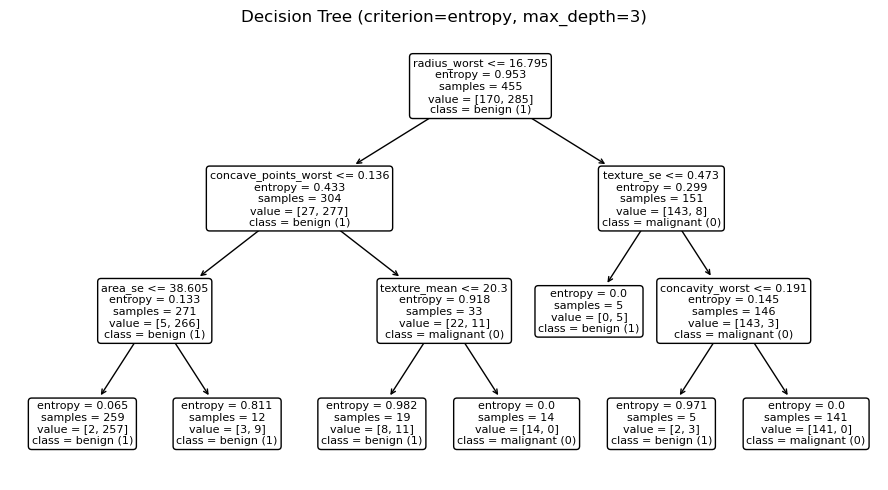

In [35]:
# Visualize the best model 
plt.figure(figsize=(9, 5))
plot_tree(
    best_clf,
    feature_names=list(X.columns),
    class_names=target_names,
    filled=False,      # keep default; no custom colors
    impurity=True,
    rounded=True,
    fontsize=8
)
plt.title(f"Decision Tree (criterion={best_criterion}, max_depth={best_depth})")
plt.tight_layout()

## Part 3: Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

### 1) Use the same training and test set as above.

### 2) Use the RandomForest classifier to create a model.

In [42]:
rf_baseline = RandomForestClassifier(
    n_estimators=200,      # a reasonable default
    criterion="gini",     # will tune later
    max_depth=None,       # will tune later
    oob_score=True,       # enable out-of-bag evaluation
    bootstrap=True,       # required for OOB
    n_jobs=-1,
    random_state=42
)
rf_baseline.fit(X_train, y_train)

rf_base_oob = getattr(rf_baseline, "oob_score_", None)
rf_base_test_acc = accuracy_score(y_test, rf_baseline.predict(X_test))

print("=== Baseline RandomForest ===")
print(f"OOB accuracy (baseline): {rf_base_oob:.4f}")
print(f"Test accuracy (baseline): {rf_base_test_acc:.4f}")

=== Baseline RandomForest ===
OOB accuracy (baseline): 0.9604
Test accuracy (baseline): 0.9561


### 3) Compare the parameters that are provided for the Random Forest classifier and Decision Tree classifier. How many are the same and how many are different?

In [45]:
rf_params = set(RandomForestClassifier().get_params().keys())
dt_params = set(DecisionTreeClassifier().get_params().keys())

common_params = sorted(rf_params & dt_params)
rf_only = sorted(rf_params - dt_params)
dt_only = sorted(dt_params - rf_params)

print("=== Parameter comparison: RandomForest vs DecisionTree ===")
print(f"Common (same names): {len(common_params)}")
print(common_params)
print(f"\nRF-only params: {len(rf_only)}")
print(rf_only)
print(f"\nDT-only params: {len(dt_only)}")
print(dt_only)

=== Parameter comparison: RandomForest vs DecisionTree ===
Common (same names): 11
['ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'random_state']

RF-only params: 7
['bootstrap', 'max_samples', 'n_estimators', 'n_jobs', 'oob_score', 'verbose', 'warm_start']

DT-only params: 1
['splitter']


### 4) Use the Grid Search method to run the model for trees of depth 1, 2, 3, 4, 5, and 6 and for the Gini Impurity and Entropy impurity measures. Also set the parameter so it will use the "out of-bag" samples for calculating accuracy.

In [48]:
grid_records = []
best_rf = None
best_rf_key = None
best_rf_oob = -np.inf

for criterion in ["gini", "entropy"]:
    for depth in range(1, 7):
        rf = RandomForestClassifier(
            n_estimators=300,     # a bit larger for stabler OOB
            criterion=criterion,
            max_depth=depth,
            oob_score=True,       # OOB evaluation
            bootstrap=True,       # must be True for OOB
            n_jobs=-1,
            random_state=42
        )
        rf.fit(X_train, y_train)

        # OOB score
        oob = getattr(rf, "oob_score_", np.nan)

        grid_records.append({
            "criterion": criterion,
            "max_depth": depth,
            "oob_accuracy": oob
        })

        # Track the best by TEST accuracy; tie-break: smaller depth, then criterion alphabetical
        key = (oob, -depth, "entropy" if criterion == "entropy" else "gini")
        if (oob > best_rf_oob) or (
            np.isclose(oob, best_rf_oob) and (depth < best_rf_key[1] if best_rf_key else True)
        ) or (
            np.isclose(oob, best_rf_oob) and depth == (best_rf_key[1] if best_rf_key else depth) and criterion < (best_rf_key[2] if best_rf_key else criterion)
        ):
            best_rf = rf
            best_rf_oob = oob
            best_rf_key = (oob, depth, criterion)

grid_df = pd.DataFrame(grid_records).sort_values(
    by=["oob_accuracy", "max_depth", "criterion"],
    ascending=[False, True, True]
).reset_index(drop=True)

print("=== RandomForest Grid (top 12 rows) ===")
print(grid_df.head(12))
print()

print("=== Best RandomForest from grid ===")
print(f"Criterion : {best_rf_key[2]}")
print(f"Max depth : {best_rf_key[1]}")
print(f"OOB acc   : {best_rf.oob_score_:.4f}")

=== RandomForest Grid (top 12 rows) ===
   criterion  max_depth  oob_accuracy
0    entropy          5      0.962637
1       gini          5      0.960440
2    entropy          6      0.960440
3       gini          4      0.958242
4       gini          6      0.958242
5    entropy          3      0.953846
6    entropy          4      0.953846
7       gini          3      0.949451
8    entropy          2      0.942857
9       gini          2      0.942857
10      gini          1      0.923077
11   entropy          1      0.920879

=== Best RandomForest from grid ===
Criterion : entropy
Max depth : 5
OOB acc   : 0.9626


### 5) Test the accuracy of RandomForest using the Test set.

In [51]:
grid_records = []
best_rf = None
best_rf_key = None
best_rf_test = -np.inf

for criterion in ["gini", "entropy"]:
    for depth in range(1, 7):
        rf = RandomForestClassifier(
            n_estimators=300,     # a bit larger for stabler OOB
            criterion=criterion,
            max_depth=depth,
            oob_score=True,       # OOB evaluation
            bootstrap=True,       # must be True for OOB
            n_jobs=-1,
            random_state=42
        )
        rf.fit(X_train, y_train)

        # Test accuracy
        test_acc = accuracy_score(y_test, rf.predict(X_test))

        grid_records.append({
            "criterion": criterion,
            "max_depth": depth,
            "test_accuracy": test_acc
        })

        # Track the best by TEST accuracy; tie-break: smaller depth, then criterion alphabetical
        key = (test_acc, -depth, "entropy" if criterion == "entropy" else "gini")
        if (test_acc > best_rf_test) or (
            np.isclose(test_acc, best_rf_test) and (depth < best_rf_key[1] if best_rf_key else True)
        ) or (
            np.isclose(test_acc, best_rf_test) and depth == (best_rf_key[1] if best_rf_key else depth) and criterion < (best_rf_key[2] if best_rf_key else criterion)
        ):
            best_rf = rf
            best_rf_test = test_acc
            best_rf_key = (test_acc, depth, criterion)

grid_df = pd.DataFrame(grid_records).sort_values(
    by=["test_accuracy", "max_depth", "criterion"],
    ascending=[False, True, True]
).reset_index(drop=True)

print("=== RandomForest Grid (top 12 rows) ===")
print(grid_df.head(12))
print()

print("=== Best RandomForest from grid ===")
print(f"Criterion : {best_rf_key[2]}")
print(f"Max depth : {best_rf_key[1]}")
print(f"Test acc  : {best_rf_test:.4f}")

=== RandomForest Grid (top 12 rows) ===
   criterion  max_depth  test_accuracy
0    entropy          3       0.956140
1       gini          3       0.956140
2    entropy          4       0.956140
3       gini          4       0.956140
4    entropy          5       0.956140
5       gini          5       0.956140
6    entropy          6       0.947368
7       gini          6       0.947368
8    entropy          2       0.938596
9       gini          2       0.938596
10   entropy          1       0.929825
11      gini          1       0.929825

=== Best RandomForest from grid ===
Criterion : entropy
Max depth : 3
Test acc  : 0.9561


### 6) Compare the performance of Decision Tree with Boost and Random Forest.

In [54]:
# AdaBoost: simple, standard setup
# Default base estimator is DecisionTree(max_depth=1) internally when not specified in modern sklearn;
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=200,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X_train, y_train)
ada_test_acc = accuracy_score(y_test, ada.predict(X_test))

# GradientBoost
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,  
    max_depth=3,       
    random_state=42
)
gb.fit(X_train, y_train)
gb_test_acc = accuracy_score(y_test, gb.predict(X_test))

# Compare all three
comparison = pd.DataFrame([
    {"model": "Decision Tree (best grid)", "test_accuracy": best_acc,
     "detail": f"criterion={best_criterion}, max_depth={best_depth}"},
    {"model": "Random Forest (best grid)", "test_accuracy": best_rf_test,
     "detail": f"criterion={best_rf_key[2]}, max_depth={best_rf_key[1]}, oob={best_rf.oob_score_:.4f}, Test acc: {best_rf_test}"},
    {"model": "AdaBoost (Decision Stumps)", "test_accuracy": ada_test_acc,
     "detail": "estimator=DecisionTree(max_depth=1), n_estimators=200"},
    {"model": "GradientBoost ", "test_accuracy": gb_test_acc,
     "detail": "estimator=DecisionTree(max_depth=3), n_estimators=200"}
]).sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)

print("=== Model comparison (Test accuracy) ===")
print(comparison)

=== Model comparison (Test accuracy) ===
                        model  test_accuracy  \
0   Random Forest (best grid)       0.956140   
1  AdaBoost (Decision Stumps)       0.956140   
2              GradientBoost        0.956140   
3   Decision Tree (best grid)       0.947368   

                                              detail  
0  criterion=entropy, max_depth=3, oob=0.9538, Te...  
1  estimator=DecisionTree(max_depth=1), n_estimat...  
2  estimator=DecisionTree(max_depth=3), n_estimat...  
3                     criterion=entropy, max_depth=3  


All three ensemble methods (Random Forest, AdaBoost, and Gradient Boosting) outperformed the single Decision Tree.
The Decision Tree achieved a test accuracy of **≈0.947**, while Random Forest, AdaBoost, and Gradient Boosting all reached about **0.956** on the same test set.

The ensembles improved performance because they reduce overfitting and variance compared to a single tree:

* **Random Forest** achieved the best overall and most stable accuracy by averaging many de-correlated trees.
* **AdaBoost** and **Gradient Boosting** performed similarly, both improving accuracy by sequentially combining weak learners.
* **Decision Tree** alone showed slightly lower accuracy and higher variance.

## Part 4: XGBoost

This is a method that we have not discussed in class but has gained popularity. Explain how XGBoost works and compare it to Adaboost and Gradientbook. Use diagrams to explain if its helpful.

### 1 How XGBoost Works

1. **Start with a base prediction**, usually the mean of the target values.
2. **Compute the gradient (and optionally the second derivative / Hessian)** of the loss function for each sample.
3. **Fit a new decision tree** to predict these gradients (residuals).
4. **Update predictions** by adding the new tree’s output multiplied by a learning rate.
5. **Repeat** for a given number of boosting rounds.

The training minimizes a **regularized objective function**:

$
\text{Obj} = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k)
$

where

$
\Omega(f_k) = \gamma T + \frac{1}{2} \lambda | w |^2
$

adds penalties for tree complexity (number of leaves (T)) and leaf weights ((w)).

---

### 2 Comparison with AdaBoost and Gradient Boosting
| Aspect                           | **AdaBoost**                                                          | **Gradient Boosting**                                     | **XGBoost**                                                                                                      |
| -------------------------------- | --------------------------------------------------------------------- | --------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------- |
| **Base Learner**                 | Weak classifiers (often depth-1 stumps)                          | Decision trees (depth 1–3 common)        | Optimized decision trees                                                                                        |
| **Boosting Principle**           | Reweight misclassified samples | Fits to residuals (gradients)         | Fit to **gradients + Hessians** for more precise updates                 
| **Regularization**               | None                                | Limited (tree depth, subsampling)                         | **Built-in L1/L2** on leaf weights + tree complexity penalty (γ for leaves)                                      |
| **Handling Missing Data**        | Not built-in                              | Not built-in                          | **Built-in**: learns default split direction for missing values                                                  |
| **Parallelization / Speed**      | Slower; sequential reweighting                                        | Moderate; sequential but can parallelize some parts       | **Highly optimized & parallelized** split finding; very fast                                                     |
| **Overfitting Control**          | **Sensitive** to noise/outliers                                       | **Moderate** (tuned by depth, subsampling, learning rate) | **Strong** due to regularization + subsampling + shrinkage                                                       |
| **Performance (typical)**        | Good on small/simple datasets                                         | Strong baseline on many tasks                             | Often **state-of-the-art** in practice                                                                           |
| **Interpretability**             | Weak (many stumps)                                                    | Moderate (trees + feature importances)                    | Moderate（trees + gain/cover/weight importances）                                                                  |
| **Common Hyperparams**           | `n_estimators`, `learning_rate`, base stump depth                     | `n_estimators`, `learning_rate`, `max_depth`, `subsample` | Above **plus** `reg_lambda` (L2), `reg_alpha` (L1), `gamma`, `colsample_bytree/level/bynode`, `min_child_weight` |
| **When to Prefer**               | Very fast/simple baselines with stumps                                | Solid default when you want control & simplicity          | Best when you need **speed, regularization, robustness**, and top accuracy                                       |

#### Diagram (conceptual)

```text
 AdaBoost:           Gradient Boosting:          XGBoost:
  ↑ weight samples     ↑ fit residuals             ↑ fit 1st & 2nd gradients
  │                    │                           │
[Tree 1] → [Tree 2] → [Tree 3] → ...         [Optimized Trees + Regularization]
```

---
XGBoost extends Gradient Boosting by adding **regularization, second-order optimization, and parallel computation**, making it faster and more accurate.


## Bonus: Information Gain

### 5.1) What is the value of log2(B)?


For DNA, the alphabet has **four possible bases**: $B = 4$

Compute ( $\log_2(B)$ ): $\log_2(4) = 2$

---

This means that the **maximum possible information per DNA position** (if perfectly conserved) is **2 bits**, because distinguishing among four equally likely nucleotides (A, C, G, T) requires **2 bits** of information.


### 5.2) Why does that addition have to be there?

We add it because we want **information content** — not raw entropy.

**Entropy**: **uncertainty**

**information content**: how much **certainty** there is **compared to the maximum randomness**.

So, by adding ( $\log_2(B)$ ), we’re computing:

$
I(i) = \text{Maximum possible entropy} - \text{Observed entropy}
$

That is:

$
I(i) = \log_2(B) - H(i)
$, where $H(i) = - \sum P(b,i)\log_2(P(b,i))$.

* If the bases are **uniformly random** → ( H(i) = \log_2(B) ), so ( I(i) = 0 ).
  → No information (no pattern). -**0 bits**
* If the position is **perfectly conserved** → ( H(i) = 0 ), so ( I(i) = \log_2(B) = 2 ) bits.
  → Maximum information (full certainty). -**2 bits**

---

$\log_2(B)$ represents the **maximum possible entropy**, allowing us to measure **how much information is gained compared to total randomness**.


### 5.3) Can you think of an intuitive log base that would allow you to remove the log2(B) addition and just use our traditional negative sign to calculate the entropy of a DNA string?

We know that the maximum entropy (when all bases are equally likely) is:

$
H_{\text{max}} = -((1/B)*\log_b(1/B))*B = log_b(B)
$

If we want ( $H_{\text{max}} = 1 $), then:
$
\log_b(B) = 1
$

That means:
$
b = B
$

For DNA, (B = 4), so:
$
b = 4
$

That is, use **log base 4**.

---
If we use **log base 4**, then the maximum entropy of a DNA sequence will be **1**, so the “+ log₂(B)” term is no longer needed.

### 5.4) Extending that logic, what would be an intuitive log base to generate a logo for a string of amino acids?

For amino acids the alphabet size is (B=20).

* If we keep the usual “information‐content in bits” form, I’d write
  $
  I(i)=\log_2(20)+\sum_{a\in\mathcal{A}} p(a,i)\log_2 p(a,i),
  $
  so the maximum information per position is ($\log_2 20 \approx 4.322$) bits.

* If we want to **remove the (\log_2(B)) term** by choosing an intuitive log base, pick the base equal to the alphabet size:
  $
  H_{20}(i)=-\sum p(a,i)\log_{20} p(a,i)
  $
  (max entropy = 1), and information content is ($I(i)=1-H_{20}(i)$).

  
---
**In short:** the intuitive base is **20** 